# Motorcycle Recommender System ด้วย Neo4j

นำข้อมูลจาก `664245008_Motorcycle_RecommenderSystem.ipynb` มาใช้ใน Neo4j: ผู้ใช้ 10 คน รถมอเตอร์ไซค์ 10 รุ่น และความชอบ 21 รายการ ระบบแนะนำรุ่นที่ผู้ใช้คนอื่นซึ่งชอบรถรุ่นเดียวกันสนใจ

## 1. เชื่อมต่อ Neo4j Aura

ใส่ URI และชื่อผู้ใช้ของฐานข้อมูลตัวเอง แล้วป้อนรหัสผ่านเมื่อโปรแกรมถาม

In [ ]:
%pip -q install neo4j networkx matplotlib pandas

In [ ]:
from getpass import getpass
from neo4j import GraphDatabase

URI = "neo4j+s://7b607e07.databases.neo4j.io"
USERNAME = "neo4j"
PASSWORD = getpass("Neo4j password: ")
driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))
driver.verify_connectivity()
print("เชื่อมต่อ Neo4j สำเร็จ")

Neo4j password: ··········
เชื่อมต่อ Neo4j สำเร็จ


In [ ]:
DATABASE = "neo4j"  # เปลี่ยนหากฐานข้อมูลของคุณใช้ชื่ออื่น

## 2. สร้างโหนด User และ Motorcycle

In [ ]:
users = ['Mint', 'Non', 'Fah', 'Ton', 'Aom', 'Boss', 'Jane', 'Kit', 'May', 'Palm']
motorcycles = ['Honda CB150R', 'Yamaha MT-15', 'Kawasaki Ninja 400', 'Vespa Primavera', 'GPX Drone', 'Honda Click 160', 'Yamaha XMAX', 'Kawasaki Z650', 'Suzuki GSX-R150', 'Royal Enfield Classic 350']
print(len(users), "users;", len(motorcycles), "motorcycles")

10 users; 10 motorcycles


In [ ]:
driver.execute_query("UNWIND $names AS name MERGE (:User {name: name})", names=users, database_=DATABASE)
driver.execute_query("UNWIND $names AS name MERGE (:Motorcycle {name: name})", names=motorcycles, database_=DATABASE)
print("สร้างโหนดเรียบร้อย")

สร้างโหนดเรียบร้อย


## 3. สร้างความสัมพันธ์ LIKES

ความสัมพันธ์มีรูปแบบ `(User)-[:LIKES]->(Motorcycle)` โดยใช้ข้อมูลจากโน้ตบุ๊กต้นทางทุกคู่

In [ ]:
likes = [('Mint', 'Honda CB150R'), ('Mint', 'Yamaha MT-15'), ('Non', 'Honda CB150R'), ('Non', 'Yamaha MT-15'), ('Non', 'Vespa Primavera'), ('Fah', 'Honda CB150R'), ('Fah', 'Kawasaki Ninja 400'), ('Ton', 'Vespa Primavera'), ('Ton', 'GPX Drone'), ('Aom', 'Honda Click 160'), ('Aom', 'Yamaha XMAX'), ('Boss', 'Kawasaki Z650'), ('Boss', 'Suzuki GSX-R150'), ('Jane', 'Honda Click 160'), ('Jane', 'Royal Enfield Classic 350'), ('Kit', 'Yamaha XMAX'), ('Kit', 'Kawasaki Z650'), ('May', 'Suzuki GSX-R150'), ('May', 'Honda CB150R'), ('Palm', 'Royal Enfield Classic 350'), ('Palm', 'GPX Drone')]
print("จำนวนความสัมพันธ์:", len(likes))

จำนวนความสัมพันธ์: 21


In [ ]:
likes_data = [{"user": user, "motorcycle": motorcycle} for user, motorcycle in likes]
driver.execute_query("""
UNWIND $rows AS row
MATCH (u:User {name: row.user}), (m:Motorcycle {name: row.motorcycle})
MERGE (u)-[:LIKES]->(m)
""", rows=likes_data, database_=DATABASE)
print("สร้าง LIKES เรียบร้อย")

สร้าง LIKES เรียบร้อย


In [ ]:
result = driver.execute_query("""
MATCH (u:User) WHERE u.name IN $users
OPTIONAL MATCH (u)-[r:LIKES]->(m:Motorcycle) WHERE m.name IN $motorcycles
RETURN count(DISTINCT u) AS users, count(DISTINCT m) AS liked_motorcycles, count(DISTINCT r) AS likes
""", users=users, motorcycles=motorcycles, database_=DATABASE)
print(dict(result.records[0]))
print("รถทั้งหมดในชุดข้อมูล:", len(motorcycles))

{'users': 10, 'liked_motorcycles': 10, 'likes': 21}
รถทั้งหมดในชุดข้อมูล: 10


## 4. วาดกราฟความชอบ

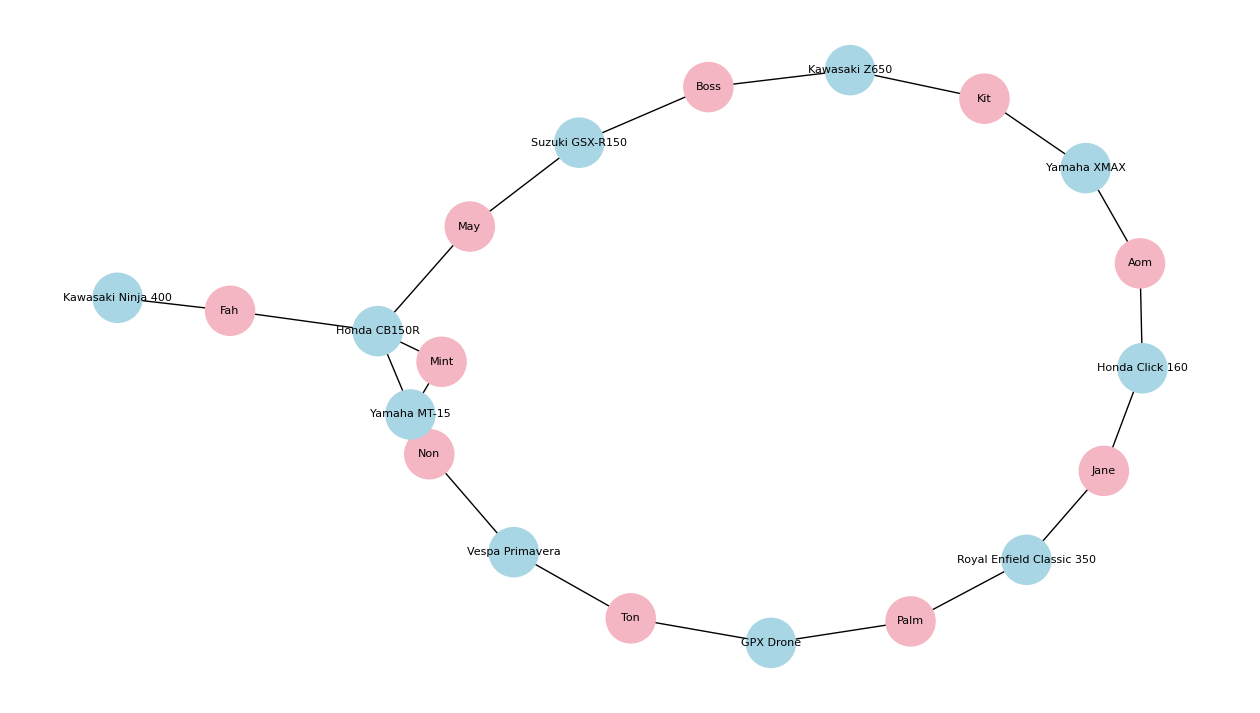

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

result = driver.execute_query("""
MATCH (u:User)-[:LIKES]->(m:Motorcycle)
WHERE u.name IN $users AND m.name IN $motorcycles
RETURN u.name AS user, m.name AS motorcycle
""", users=users, motorcycles=motorcycles, database_=DATABASE)
G = nx.Graph()
G.add_nodes_from(users, bipartite=0)
G.add_nodes_from(motorcycles, bipartite=1)
G.add_edges_from((r["user"], r["motorcycle"]) for r in result.records)
plt.figure(figsize=(16, 9))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(G, pos, node_size=1250, font_size=8, node_color=["#f4b6c2" if n in users else "#a9d6e5" for n in G])
plt.axis("off")
plt.show()

## 5. คำถามจากกราฟ

In [ ]:
result = driver.execute_query("""
MATCH (:User {name: $name})-[:LIKES]->(m:Motorcycle)
RETURN m.name AS motorcycle ORDER BY motorcycle
""", name="Mint", database_=DATABASE)
print("รถที่ Mint ชอบ:", [r["motorcycle"] for r in result.records])

รถที่ Mint ชอบ: ['Honda CB150R', 'Yamaha MT-15']


In [ ]:
result = driver.execute_query("""
MATCH (:User {name: $name})-[:LIKES]->(m:Motorcycle)<-[:LIKES]-(other:User)
WHERE other.name <> $name
RETURN m.name AS motorcycle, collect(other.name) AS similar_users ORDER BY motorcycle
""", name="Mint", database_=DATABASE)
for r in result.records: print(r["motorcycle"], "→", r["similar_users"])

Honda CB150R → ['Non', 'Fah', 'May']
Yamaha MT-15 → ['Non']


## 6. แนะนำรถมอเตอร์ไซค์

เดินกราฟ 3 ช่วง `ผู้ใช้ → รุ่นที่ชอบ → ผู้ใช้อื่น → รุ่นใหม่` คะแนนคือจำนวนเส้นทางที่ไปถึงรถรุ่นนั้น ไม่นับรุ่นที่ผู้ใช้ชอบอยู่แล้ว

In [ ]:
def recommend_motorcycles(target_user, top_n=None):
    if target_user not in users:
        raise ValueError(f"ไม่พบผู้ใช้: {target_user}")
    if top_n is not None and (not isinstance(top_n, int) or top_n < 1):
        raise ValueError("top_n ต้องเป็นจำนวนเต็มบวก")
    result = driver.execute_query("""
    MATCH (me:User {name: $name})-[:LIKES]->(:Motorcycle)<-[:LIKES]-(other:User)-[:LIKES]->(rec:Motorcycle)
    WHERE other <> me AND NOT EXISTS { (me)-[:LIKES]->(rec) }
    RETURN rec.name AS motorcycle, count(*) AS score
    ORDER BY score DESC, motorcycle ASC
    """, name=target_user, database_=DATABASE)
    recommendations = [(r["motorcycle"], r["score"]) for r in result.records]
    return recommendations[:top_n] if top_n is not None else recommendations

In [ ]:
print("Mint →", recommend_motorcycles("Mint"))
print("Fah →", recommend_motorcycles("Fah"))
print("Non →", recommend_motorcycles("Non"))

Mint → [('Vespa Primavera', 2), ('Kawasaki Ninja 400', 1), ('Suzuki GSX-R150', 1)]
Fah → [('Yamaha MT-15', 2), ('Suzuki GSX-R150', 1), ('Vespa Primavera', 1)]
Non → [('GPX Drone', 1), ('Kawasaki Ninja 400', 1), ('Suzuki GSX-R150', 1)]


In [ ]:
for user in users:
    print(f"{user:5s} → {recommend_motorcycles(user, top_n=3)}")

Mint  → [('Vespa Primavera', 2), ('Kawasaki Ninja 400', 1), ('Suzuki GSX-R150', 1)]
Non   → [('GPX Drone', 1), ('Kawasaki Ninja 400', 1), ('Suzuki GSX-R150', 1)]
Fah   → [('Yamaha MT-15', 2), ('Suzuki GSX-R150', 1), ('Vespa Primavera', 1)]
Ton   → [('Honda CB150R', 1), ('Royal Enfield Classic 350', 1), ('Yamaha MT-15', 1)]
Aom   → [('Kawasaki Z650', 1), ('Royal Enfield Classic 350', 1)]
Boss  → [('Honda CB150R', 1), ('Yamaha XMAX', 1)]
Jane  → [('GPX Drone', 1), ('Yamaha XMAX', 1)]
Kit   → [('Honda Click 160', 1), ('Suzuki GSX-R150', 1)]
May   → [('Yamaha MT-15', 2), ('Kawasaki Ninja 400', 1), ('Kawasaki Z650', 1)]
Palm  → [('Honda Click 160', 1), ('Vespa Primavera', 1)]


Mint จะได้ `Vespa Primavera`, `Kawasaki Ninja 400` และ `Suzuki GSX-R150` อย่างละ 1 คะแนนจากข้อมูลชุดนี้ กรณีคะแนนเท่ากันจะเรียงตามชื่อรุ่น

## 7. ดูกราฟใน Neo4j Browser

```cypher
MATCH p = (:User)-[:LIKES]->(:Motorcycle)
RETURN p
```

In [ ]:
driver.close()
print("ปิดการเชื่อมต่อแล้ว")

ปิดการเชื่อมต่อแล้ว
